<a href="https://colab.research.google.com/github/bellakinch/Behavioral-Indicators-of-AI-Generated-Phishing-Content/blob/main/Behavior_Indicators_of_AI_generated_phishing_content_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score
)

import joblib

# CONNECT GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# FILE PATHS
# ==========================================

CORPUS = "/content/drive/MyDrive/labeled_corpus_clean.csv"
OUTDIR = "/content/drive/MyDrive"

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(CORPUS)

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

# ==========================================
# FEATURES USED FOR TRAINING
# ==========================================

FEATURES = [
    "urgency",
    "authority",
    "emotion",
    "targeting",
    "action"
]

# ==========================================
# MODELS TO COMPARE
# ==========================================

MODELS = {

    "LogisticRegression":
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),

    "DecisionTree":
        DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ),

    "RandomForest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "GradientBoosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "SVM":
        SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        )
}

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

def feature_importance(model):

    if hasattr(model, "feature_importances_"):
        vals = model.feature_importances_

    elif hasattr(model, "coef_"):
        vals = np.abs(model.coef_).ravel()

    else:
        return {}

    vals = vals / vals.sum()

    return {
        f: round(float(v), 3)
        for f, v in sorted(
            zip(FEATURES, vals),
            key=lambda x: -x[1]
        )
    }

# ==========================================
# TRAINING FUNCTION
# ==========================================

def run_task(df, target_col, positive_label, task_name):

    print("\n" + "=" * 60)
    print("TASK:", task_name)
    print("=" * 60)

    # X = behavioral indicators
    X = df[FEATURES]

    # Convert target to 0/1
    y = (df[target_col] == positive_label).astype(int)

    print("Samples:", len(y))
    print("Positive:", y.sum())
    print("Negative:", len(y) - y.sum())

    # --------------------------------------
    # 5-Fold Cross Validation
    # --------------------------------------

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    results = {}

    print("\nModel Comparison")
    print("-" * 40)

    for name, model in MODELS.items():

        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="f1",
            n_jobs=-1
        )

        results[name] = scores.mean()

        print(
            f"{name:20s}"
            f" F1 = {scores.mean():.3f}"
        )

    # --------------------------------------
    # Pick Best Model
    # --------------------------------------

    best_name = max(results, key=results.get)

    print("\nBest Model:", best_name)

    best_model = MODELS[best_name]

    # --------------------------------------
    # 80/20 Train Test Split
    # --------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # --------------------------------------
    # Train Model
    # --------------------------------------

    best_model.fit(X_train, y_train)

    # --------------------------------------
    # Predictions
    # --------------------------------------

    y_pred = best_model.predict(X_test)

    # --------------------------------------
    # Metrics
    # --------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    probabilities = best_model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, probabilities)

    print("\nAccuracy:", round(accuracy, 3))
    print("F1 Score:", round(f1, 3))
    print("ROC AUC:", round(auc, 3))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # --------------------------------------
    # Feature Importance
    # --------------------------------------

    importance = feature_importance(best_model)

    print("\nFeature Importance")

    for feature, score in importance.items():
        print(feature, "=", score)

    # --------------------------------------
    # Save Trained Model
    # --------------------------------------

    best_model.fit(X, y)

    joblib.dump(
        best_model,
        f"{OUTDIR}/model_{task_name}.joblib"
    )

    return {
        "best_model": best_name,
        "accuracy": round(accuracy, 3),
        "f1": round(f1, 3),
        "auc": round(auc, 3),
        "feature_importance": importance
    }

# ==========================================
# MAIN
# ==========================================

def main():

    results = {}

    # AI vs Human
    results["ai_vs_human"] = run_task(
        df,
        target_col="source",
        positive_label="llm",
        task_name="ai_vs_human"
    )

    # Phishing vs Legitimate
    results["phishing_vs_legit"] = run_task(
        df,
        target_col="is_phishing",
        positive_label=1,
        task_name="phishing_vs_legit"
    )

    with open(
        f"{OUTDIR}/classifier_results.json",
        "w"
    ) as f:
        json.dump(results, f, indent=2)

    print("\nSaved Results:")
    print("classifier_results.json")
    print("model_ai_vs_human.joblib")
    print("model_phishing_vs_legit.joblib")

# ==========================================
# RUN EVERYTHING
# ==========================================

main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape:
(4000, 9)

Columns:
['email_id', 'source', 'is_phishing', 'urgency', 'authority', 'emotion', 'targeting', 'action', 'clean_text']

First 5 Rows:
   email_id source  is_phishing  urgency  authority  emotion  targeting  \
0         1  human            1        2          0        0          0   
1         2  human            1        2          0        0          0   
2         3  human            1        0          0        0          0   
3         4  human            1        0          0        0          0   
4         5  human            1        0          0        0          0   

   action                                         clean_text  
0       2  Your MetaMask wallet will be suspended. Verify...  
1       2  Your MetaMask wallet will be suspended. Verify...  
2       0  Your shipment is on the way. Announcing JotFor...  
3       

Research Findings
Behavioral Indicators of AI-Generated Phishing Content

Classification performance
- The paper reported Random Forest as the strongest classifier for both tasks. AI-generated
versus human-written classification achieved higher accuracy, F1 score, and ROC-AUC
than phishing versus legitimate classification.
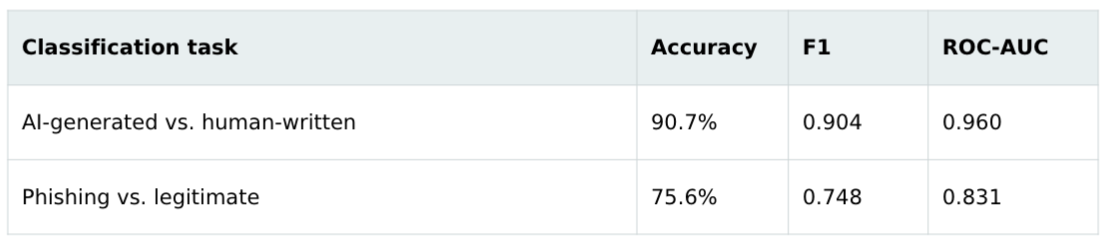


AI-generated versus human-written emails
- Targeted messaging was the most influential indicator, with feature importance of 0.624
(62.4%). The model correctly classified 726 of 800 test emails: 377 human-written and
349 AI-generated. It misclassified 23 human-written emails as AI-generated and 51
AI-generated emails as human-written.
- Human-written emails: precision 0.88, recall 0.94.
- AI-generated emails: precision 0.94, recall 0.87




Phishing versus legitimate emails
- Action requests were the most influential indicator, with feature importance of 0.335
(33.5%). The model correctly classified 605 of 800 test emails: 315 legitimate and 290
phishing. It incorrectly flagged 85 legitimate emails as phishing and missed 110 phishing
emails.
- Legitimate emails: precision 0.74, recall 0.79.
- Phishing emails: precision 0.77, recall 0.72.
Overall findings
- Behavioral indicators provided useful information for both tasks, with different indicators
contributing most strongly to each. Targeting was most important for AI-generated
content identification, while action requests were most important for phishing
identification. Phishing detection produced more false positives and false negatives than
AI-generated content detection.
